# Linear Mixed-Effects Model — Response Time

1. **Phonological similarity of the string** (`phon_sim_c`) — mean pairwise cosine similarity among German letter names in the encoding string.
2. **Probe–string phonological similarity** (`probe_phon_sim_c`) — mean cosine similarity between the probe letter and the letters in the encoding string (excluding the probe itself on IN trials). Low values = phonologically distinct probe = expected faster RT.
4. **Letter frequency** —  cumulative session
   (running proportions up to and including each trial).


Full model:
```
RT ~ DecodingAccuracy              (mean-centred over all trials)
   + PhonStringSimilarity           (mean-centred over all trials)
   + ProbeStringSimilarity          (mean-centred over all trials)
   + C(trial_type)                  (IN vs OUT; OUT = reference)
   + C(size)                        (set size 4/6/8; 4 = reference)
   + C(probe)                       (probe letter; G = reference)
   + letter_cum_session_c         (cumulative session frequency up to trial t, mean-centred)
   + (1 | subject)
```

In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import re
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

## 1. Phonological Feature Matrix (German)

Each of the 15 consonant letters is described by 17 binary IPA features
based on its **German letter name** (Hochdeutsch standard).

| Letter | German name | IPA | Rhyme group |
|--------|------------|-----|-------------|
| B | be | /beː/ | /eː/ |
| C | ze | /tseː/ | /eː/ |
| D | de | /deː/ | /eː/ |
| F | ef | /ɛf/ | /ɛ_/ (vowel-initial) |
| G | ge | /ɡeː/ | /eː/ |
| H | ha | /haː/ | /aː/ |
| K | ka | /kaː/ | /aː/ |
| L | el | /ɛl/ | /ɛ_/ (vowel-initial) |
| N | en | /ɛn/ | /ɛ_/ (vowel-initial) |
| P | pe | /peː/ | /eː/ |
| R | er | /ɛr/ | /ɛ_/ (vowel-initial) |
| S | es | /ɛs/ | /ɛ_/ (vowel-initial) |
| T | te | /teː/ | /eː/ |
| V | fau | /faʊ/ | /aʊ/ (unique) |
| Z | zet | /tsɛt/ | /ɛ_/ |

**Rhyme groups:** /eː/ → B C D G P T · /aː/ → H K · /ɛ_/ → F L N R S Z · /aʊ/ → V

**Key differences from English** that change the similarity structure:
- C = /tseː/ and Z = /tsɛt/ share the same affricate onset /ts/
- H = /haː/ rhymes with K = /kaː/ (unlike English H = /eɪtʃ/)
- V = /faʊ/ has a unique rhyme — least confusable of all letters
- G = /ɡeː/ is a plain velar stop (not the affricate /dʒ/ of English)
- The critical /eː/ rhyme group is **B C D G P T** (6 letters, not 7 as in English /iː/)

Features: **Manner** (stop, fricative, affricate, nasal, lateral, trill) +
**Place** (bilabial, labiodental, alveolar, velar, glottal) +
**Voicing** + **vowel_onset** + **4 rhyme groups** = 17 features total.

Trial-level `phon_sim` = mean pairwise cosine similarity of the letters
in that trial's encoding string.


In [2]:
LETTERS = ['B','C','D','F','G','H','K','L','N','P','R','S','T','V','Z']

# German letter name IPA transcriptions:
# B=/beː/ C=/tseː/ D=/deː/ F=/ɛf/  G=/ɡeː/ H=/haː/ K=/kaː/
# L=/ɛl/  N=/ɛn/  P=/peː/ R=/ɛr/  S=/ɛs/  T=/teː/ V=/faʊ/ Z=/tsɛt/

FEAT_NAMES = [
    'voiced',         #  0
    'bilabial',       #  1
    'labiodental',    #  2
    'alveolar',       #  3
    'velar',          #  4
    'glottal',        #  5  ← H = /h/ in German
    'affricate',      #  6
    'fricative',      #  7
    'nasal',          #  8
    'stop',           #  9
    'lateral',        # 10  ← /l/
    'trill',          # 11  ← German /r/
    'vowel_onset',    # 12: name starts with /ɛ/ (F L N R S)
    'rhyme_ee',       # 13: /eː/ coda — B C D G P T
    'rhyme_aa',       # 14: /aː/ coda — H K
    'rhyme_eps',      # 15: /ɛ_/ coda — F L N R S Z
    'rhyme_au',       # 16: /aʊ/ coda — V (unique)
]

# Rows: B C D F G H K L N P R S T V Z
# Cols: [voiced, bilabial, labiodental, alveolar, velar, glottal,
#        affricate, fricative, nasal, stop, lateral, trill,
#        vowel_onset, rhyme_ee, rhyme_aa, rhyme_eps, rhyme_au]
FEAT_MATRIX = np.array([
 # B  /beː/ — voiced bilabial stop, rhyme /eː/
 [1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
 # C  /tseː/ — voiceless alveolar affricate /ts/, rhyme /eː/
 [0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
 # D  /deː/ — voiced alveolar stop, rhyme /eː/
 [1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
 # F  /ɛf/ — vowel-initial; coda = voiceless labiodental fricative, rhyme /ɛ_/
 [0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0],
 # G  /ɡeː/ — voiced velar stop, rhyme /eː/
 [1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
 # H  /haː/ — voiceless glottal fricative, rhyme /aː/
 [0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0],
 # K  /kaː/ — voiceless velar stop, rhyme /aː/
 [0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0],
 # L  /ɛl/ — vowel-initial; coda = voiced alveolar lateral, rhyme /ɛ_/
 [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0],
 # N  /ɛn/ — vowel-initial; coda = voiced alveolar nasal, rhyme /ɛ_/
 [1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0],
 # P  /peː/ — voiceless bilabial stop, rhyme /eː/
 [0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
 # R  /ɛr/ — vowel-initial; coda = voiced alveolar/uvular trill, rhyme /ɛ_/
 [1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0],
 # S  /ɛs/ — vowel-initial; coda = voiceless alveolar fricative, rhyme /ɛ_/
 [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0],
 # T  /teː/ — voiceless alveolar stop, rhyme /eː/
 [0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
 # V  /faʊ/ — voiceless labiodental fricative, unique rhyme /aʊ/
 [0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1],
 # Z  /tsɛt/ — voiceless alveolar affricate /ts/, rhyme /ɛ_/
 [0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
], dtype=float)

# ── Pairwise cosine similarity ──────────────────────────────────────────
norms     = np.linalg.norm(FEAT_MATRIX, axis=1, keepdims=True)
FEAT_NORM = FEAT_MATRIX / norms
COS_SIM   = FEAT_NORM @ FEAT_NORM.T

LETTER_IDX = {l: i for i, l in enumerate(LETTERS)}

sim_df = pd.DataFrame(np.round(COS_SIM, 3), index=LETTERS, columns=LETTERS)
print('German IPA pairwise cosine similarity:')
print(sim_df)

print('\nSanity checks:')
print(f'  C-Z (both /ts/ affricate): {COS_SIM[LETTER_IDX["C"],LETTER_IDX["Z"]]:.3f}  <- expect HIGH')
print(f'  H-K (both /aː/ rhyme):     {COS_SIM[LETTER_IDX["H"],LETTER_IDX["K"]]:.3f}  <- expect MED')
print(f'  B-P (voicing pair, /eː/):  {COS_SIM[LETTER_IDX["B"],LETTER_IDX["P"]]:.3f}  <- expect HIGH')
print(f'  V-B (nothing in common):   {COS_SIM[LETTER_IDX["V"],LETTER_IDX["B"]]:.3f}  <- expect 0')
print(f'  B-G (voiced stops, /eː/):  {COS_SIM[LETTER_IDX["B"],LETTER_IDX["G"]]:.3f}')

German IPA pairwise cosine similarity:
       B      C      D      F      G      H      K      L      N      P  \
B  1.000  0.289  0.750  0.000  0.750  0.000  0.289  0.224  0.224  0.866   
C  0.289  1.000  0.577  0.000  0.289  0.000  0.000  0.258  0.258  0.333   
D  0.750  0.577  1.000  0.000  0.750  0.000  0.289  0.447  0.447  0.577   
F  0.000  0.000  0.000  1.000  0.000  0.289  0.000  0.447  0.447  0.000   
G  0.750  0.289  0.750  0.000  1.000  0.000  0.577  0.224  0.224  0.577   
H  0.000  0.000  0.000  0.289  0.000  1.000  0.333  0.000  0.000  0.000   
K  0.289  0.000  0.289  0.000  0.577  0.333  1.000  0.000  0.000  0.333   
L  0.224  0.258  0.447  0.447  0.224  0.000  0.000  1.000  0.800  0.000   
N  0.224  0.258  0.447  0.447  0.224  0.000  0.000  0.800  1.000  0.000   
P  0.866  0.333  0.577  0.000  0.577  0.000  0.333  0.000  0.000  1.000   
R  0.224  0.258  0.447  0.447  0.224  0.000  0.000  0.800  0.800  0.000   
S  0.000  0.289  0.250  0.750  0.000  0.289  0.000  0.671  0.

## 2. Load Data


In [3]:
units         = np.load('../Data/units.npy',         allow_pickle=True)
info          = np.load('../Data/trial_corrInfo.npy', allow_pickle=True)
reaction      = np.load('../Data/reaction.npy',       allow_pickle=True)
letters       = np.load('../Data/letters_sep.npy',    allow_pickle=True)
probes        = np.load('../Data/probes_sep.npy',     allow_pickle=True)
subj          = np.load('../Data/subjs_sep.npy',      allow_pickle=True)

uniqueLetters = np.array([p for p in np.unique(np.concatenate(letters))
                          if p not in ['Q', 'W', 'X']])

# ── Session index ────────────────────────────────────────────────────────
# Each element of letters (before concatenation) is one session.
# We replicate the session number for every trial in it,
# mirroring how subj is built from subjs_sep.
# All included trials are already correct — no further subsetting needed.
session_idx = np.concatenate([
    np.full(len(session), s_idx, dtype=int)
    for s_idx, session in enumerate(letters)
])

subj      = np.concatenate(subj, axis=0)
uniqueSub = np.unique(subj)

print(f'Total trials:    {len(subj)}')
print(f'Unique subjects: {uniqueSub}')
print(f'Unique sessions: {len(np.unique(session_idx))} ')

Total trials:    2613
Unique subjects: [40 43 44 45 47 53 57 58 61 63 64]
Unique sessions: 35 


## 3. Pre-process Trials


In [4]:
allL = np.concatenate(letters, axis=0)
allL = [[si for si in s if si not in ['X','Q','W']] for s in allL]

allP = np.concatenate(probes, axis=0)
allP = [[si for si in s if si not in ['X','Q','W']] for s in allP]

infoALL = np.concatenate(info)
infoALL = infoALL[infoALL[:, 1] == 1]   # correct trials only
respALL = infoALL[:, -1]

## 4a. Load Decoding Accuracies


In [5]:
global_letter_acc = []
L  = 15
T1 = 2
T2 = 16
T  = T2 - T1

for k in range(50):
    al    = []
    all_L = np.load(f'../../FC_letter_decoding_updated/Results/single_letter_50_{k}.npy')
    for letter_index in range(L):
        al.append(np.diag(all_L[letter_index]))
    global_letter_acc.append(np.array(al))

global_letter_acc = np.array(global_letter_acc)   # (50, L, n_times)

global_last = np.array([
    np.cumsum(global_letter_acc[:, i, T1:T2], axis=-1)[:, -1] / T
    for i in range(L)
])  # (L, 50)

global_mean_per_letter = np.median(global_last, axis=1)  # (L,)

dictDEC = {uniqueLetters[i]: global_mean_per_letter[i]
           for i in range(len(uniqueLetters))}
print('Decoding accuracy per letter:')
print(dictDEC)

Decoding accuracy per letter:
{'B': 0.5725, 'C': 0.5549999999999999, 'D': 0.5460714285714285, 'F': 0.5964285714285714, 'G': 0.5585714285714286, 'H': 0.5, 'K': 0.5214285714285716, 'L': 0.48964285714285716, 'N': 0.5449999999999999, 'P': 0.4782142857142857, 'R': 0.5399999999999999, 'S': 0.49535714285714283, 'T': 0.5082142857142857, 'V': 0.5467857142857143, 'Z': 0.5053571428571428}


## 4b. Compute Letter Frequency

In [6]:
# Cumulative session frequency (resets each session) ────────────────
# For trial at within-session rank r (0-based):
#   freq[l] = count of trials 0..r (inclusive) where l appeared / (r+1)
# Trial 0 gives 1.0 for present letters, 0.0 for absent ones.
cum_session_freq = [None] * len(allL)
for s in np.unique(session_idx):
    mask   = np.where(session_idx == s)[0]   # global indices in session order
    counts = {l: 0 for l in uniqueLetters}
    for rank, global_i in enumerate(mask):
        for l in allL[global_i]:
            if l in counts:
                counts[l] += 1
        t_plus1 = rank + 1
        cum_session_freq[global_i] = {l: counts[l] / t_plus1 for l in uniqueLetters}

# ── Descriptive check ────────────────────────────────────────────────────
#print(f'Cum session freq    — mean over trials: {np.mean(cum_s_vals):.3f}')
#print(f'Cum subject freq    — mean over trials: {np.mean(cum_u_vals):.3f}')

## 5. Build Trial-Level DataFrame

New columns vs. original notebook:

| Column | Description |
|---|---|
| `trial_type` | String category `'IN'` / `'OUT'` (recoded from 51/52); `OUT` = reference level |
| `phon_sim` | Mean pairwise cosine similarity among German letter names in the encoding string |
| `probe_phon_sim` | Mean cosine similarity between probe and the encoding string letters (probe excluded from string on IN trials) |a
| `letter_cum_session` | Cumulative mean frequency of string letters up to and including trial *t*, within the current session (resets each session) |

In [7]:
def mean_pairwise_cosine(letter_list):
    """Mean pairwise cosine similarity among letters in a string."""
    idx = [LETTER_IDX[l] for l in letter_list if l in LETTER_IDX]
    n   = len(idx)
    if n < 2:
        return np.nan
    total, count = 0.0, 0
    for ii in range(n):
        for jj in range(ii + 1, n):
            total += COS_SIM[idx[ii], idx[jj]]
            count += 1
    return total / count


def probe_string_cosine(probe, letter_list):
    """Mean cosine similarity between probe and letters in the string.

    For IN trials the probe is present in letter_list; it is excluded so
    we measure similarity to the *other* string members only.
    For OUT trials the probe is absent, so all letters are included.
    """
    others = [l for l in letter_list if l != probe]  # excludes probe if present
    pi = LETTER_IDX.get(probe)
    if pi is None or not others:
        return np.nan
    sims = [COS_SIM[pi, LETTER_IDX[l]] for l in others if l in LETTER_IDX]
    return np.mean(sims) if sims else np.nan


rows = []

for i in range(len(infoALL)):
    letter_set   = allL[i]
    probe_single = allP[i]

    if not len(probe_single):
        continue

    probe_single = probe_single[0]
    info_single  = infoALL[i]
    inout        = info_single[3]   # 51 = IN, 52 = OUT
    rt           = info_single[4]
    set_size     = int(info_single[0])  # 4, 6, or 8
    subject_id   = subj[i]

    # ── Existing predictor: mean decoding accuracy of string letters ────
    decoding_acc = np.mean([dictDEC[l] for l in letter_set if l in dictDEC])

    # ── Letter frequency at three levels ──────────────────────────────
    s  = session_idx[i]
    su = subj[i]

    letter_cum_session = np.mean([
        cum_session_freq[i][l] for l in letter_set
        if l in cum_session_freq[i]
    ])



    # ── NEW 1: phonological similarity within the encoding string ───────
    phon_sim = mean_pairwise_cosine(letter_set)

    # ── NEW 2: phonological similarity between probe and string ─────────
    # IN: probe excluded from string before computing (compares to others)
    # OUT: probe not in string, all letters used
    probe_phon_sim = probe_string_cosine(probe_single, letter_set)


    rows.append({
        'rt':               rt,
        'predicted':        decoding_acc,
        'phon_sim':         phon_sim,
        'probe_phon_sim':   probe_phon_sim,
        
        'inout':            int(inout),        # kept for reference
        'trial_type':       'IN' if int(inout) == 51 else 'OUT',
        'size':             set_size,
        'subject':          subject_id,
        'probe':            probe_single,
        
        'letter_cum_session':  letter_cum_session,
    })

df = pd.DataFrame(rows)

# ── Categorical types ──────────────────────────────────────────────────
df['trial_type'] = df['trial_type'].astype('category')
# OUT = reference level → estimated term is C(trial_type)[T.IN]
df['trial_type'] = df['trial_type'].cat.reorder_categories(['OUT', 'IN'])

df['size']  = df['size'].astype('category')
df['probe'] = df['probe'].astype('category').cat.remove_unused_categories()

# G = reference probe (median response time)
if 'G' in df['probe'].cat.categories:
    df['probe'] = df['probe'].cat.reorder_categories(
        ['G'] + [c for c in df['probe'].cat.categories if c != 'G']
    )

print(f'DataFrame shape: {df.shape}')

print(f'\nProbe–string similarity descriptives:')
print(df['probe_phon_sim'].describe())
print(f'\nString similarity descriptives:')
print(df['phon_sim'].describe())

DataFrame shape: (2585, 10)

Probe–string similarity descriptives:
count    2585.000000
mean        0.268248
std         0.139720
min         0.000000
25%         0.164155
50%         0.275958
75%         0.364530
max         0.756940
Name: probe_phon_sim, dtype: float64

String similarity descriptives:
count    2585.000000
mean        0.268777
std         0.095119
min         0.000000
25%         0.205856
50%         0.256670
75%         0.325591
max         0.735410
Name: phon_sim, dtype: float64


## 6. Centre Predictors and Fit Model

**Centring strategy:**

| Predictor | Centring | Rationale |
|---|---|---|
| `predicted_c` | Grand mean (all trials) | Interpretable intercept |
| `phon_sim_c` | Grand mean (all trials) | Reduces collinearity with `predicted_c` |
| `probe_phon_sim_c` | Grand mean (all trials) | Same scale as `phon_sim_c` |
| `letter_cum_session_c` | Grand mean | Cumulative session frequency (resets per session) |

In [8]:
# ── Centre continuous predictors ────────────────────────────────────────
df['predicted_c']      = df['predicted']      - df['predicted'].mean()
df['phon_sim_c']       = df['phon_sim']       - df['phon_sim'].mean()
df['probe_phon_sim_c'] = df['probe_phon_sim'] - df['probe_phon_sim'].mean()
df['letter_cum_session_c'] = df['letter_cum_session'] - df['letter_cum_session'].mean()


# ── Model formula ────────────────────────────────────────────────────────
# serial_pos_norm_IN_c enters as a plain term (not an interaction):
#   - value is 0 for all OUT trials → zero contribution
#   - varies only for IN trials → slope estimated from IN variance
# probe_phon_sim_c is valid for all trials (IN and OUT)
formula = (
    'rt ~ predicted_c'
    ' + phon_sim_c'
    ' + probe_phon_sim_c'
    #' + letter_freq_session_c'
    #' + letter_freq_subj_c'
    #' + letter_freq_global_c'
    #' + letter_cum_session_c'
    #' + letter_cum_subj_c'
    ' + C(trial_type)'
    ' + C(size)'
    ' + C(probe)'
    #' + serial_pos_norm_IN_c'
)

model = smf.mixedlm(
    formula,
    df,
    groups=df['subject'],
    re_formula='1'   # random intercept per participant
)

res = model.fit(reml=False)
print(res.summary())


            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   rt        
No. Observations:   2585      Method:               ML        
No. Groups:         11        Scale:                0.5084    
Min. group size:    149       Log-Likelihood:       -2815.5323
Max. group size:    338       Converged:            Yes       
Mean group size:    235.0                                     
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            1.448    0.120 12.077 0.000  1.213  1.683
C(trial_type)[T.IN] -0.146    0.028 -5.145 0.000 -0.201 -0.090
C(size)[T.6]         0.218    0.033  6.543 0.000  0.153  0.283
C(size)[T.8]         0.341    0.035  9.612 0.000  0.272  0.411
C(probe)[T.B]        0.100    0.079  1.264 0.206 -0.055  0.255
C(probe)[T.C]        0.185    0.080  2.319 0.020  0.029  0.341
C(pro

## 7. Clean Results Table

In [9]:
fe_params = res.fe_params
fe_se     = res.bse_fe
conf_int  = res.conf_int().loc[fe_params.index]
fe_pvals  = res.pvalues.loc[fe_params.index]
z_values  = fe_params / fe_se

ci_strings = conf_int.apply(
    lambda r: f'[{r[0]:.3f}, {r[1]:.3f}]', axis=1
)

results_table = pd.DataFrame({
    'Coefficient': fe_params.round(3),
    'CI':          ci_strings,
    't-value':     z_values.round(3),
    'p-value':     fe_pvals.apply(lambda p: f'{p:.2e}'),
})

# ── FDR within probe and size families ────────────────────────────────
probe_mask = fe_pvals.index.str.startswith('C(probe)')
size_mask  = fe_pvals.index.str.startswith('C(size)')

_, probe_fdr, _, _ = multipletests(fe_pvals[probe_mask], method='fdr_bh')
_, size_fdr,  _, _ = multipletests(fe_pvals[size_mask],  method='fdr_bh')

results_table['p-FDR'] = ''
results_table.loc[probe_mask, 'p-FDR'] = [f'{p:.2e}' for p in probe_fdr]
results_table.loc[size_mask,  'p-FDR'] = [f'{p:.2e}' for p in size_fdr]

# Merge: use FDR-corrected p where available, raw p otherwise
results_table['p-value'] = np.where(
    results_table['p-FDR'].astype(str).str.len() > 0,
    results_table['p-FDR'],
    results_table['p-value']
)
results_table = results_table.drop(columns=['p-FDR'])

# ── Rename terms to human-readable labels ─────────────────────────────
def clean_term(term):
    if term == 'Intercept':               return 'Intercept'
    if term == 'predicted_c':             return 'Decoding accuracy'
    if term == 'phon_sim_c':              return 'Phonological similarity (string)'
    if term == 'probe_phon_sim_c':        return 'Phonological similarity (probe–string)'
    if term == 'letter_cum_session_c': return 'Letter frequency, cumulative (session)'
    # C(trial_type)[T.IN] → 'IN vs. OUT'
    # C(size)[T.6]        → '6 vs. 4' etc.
    # C(probe)[T.B]       → 'B vs. G' etc.
    m = re.match(r'C\((?P<var>[^)]+)\)\[T\.(?P<lvl>.+)\]$', term)
    if m:
        var = m.group('var')
        lvl = m.group('lvl')
        ref = df[var].cat.categories[0]
        return f'{lvl} vs. {ref}'
    return term

results_table.index = [clean_term(t) for t in results_table.index]

# ── Reorder: key predictors first, covariates after ───────────────────
priority = [
    'Intercept',
    'Decoding accuracy',
    'Phonological similarity (string)',
    'Phonological similarity (probe–string)',
    'Serial position, normalised (IN trials)',
    'Letter frequency, cumulative (session)',
]
idx_order     = priority + [x for x in results_table.index if x not in priority]
results_table = results_table.reindex(
    [x for x in idx_order if x in results_table.index]
)

results_table = results_table[['Coefficient', 'CI', 't-value', 'p-value']]

results_table.to_excel('Mixed-effect_RT_revised.xlsx')
results_table

,Coefficient,CI,t-value,p-value
Intercept,1.448,"[1.213, 1.683]",12.077,1.39e-33
Decoding accuracy,-2.646,"[-4.875, -0.417]",-2.327,2.00e-02
Phonological similarity (string),-0.453,"[-0.774, -0.132]",-2.764,5.72e-03
Phonological similarity (probe–string),0.533,"[0.242, 0.824]",3.591,3.30e-04
IN vs. OUT,-0.146,"[-0.201, -0.090]",-5.145,2.67e-07
6 vs. 4,0.218,"[0.153, 0.283]",6.543,6.03e-11
8 vs. 4,0.341,"[0.272, 0.411]",9.612,1.42e-21
B vs. G,0.100,"[-0.055, 0.255]",1.264,4.81e-01
C vs. G,0.185,"[0.029, 0.341]",2.319,2.06e-01
D vs. G,0.046,"[-0.110, 0.202]",0.577,7.86e-01


In [10]:
9.65e-03

0.00965

## 8. Phonological similarity matrix heatmap


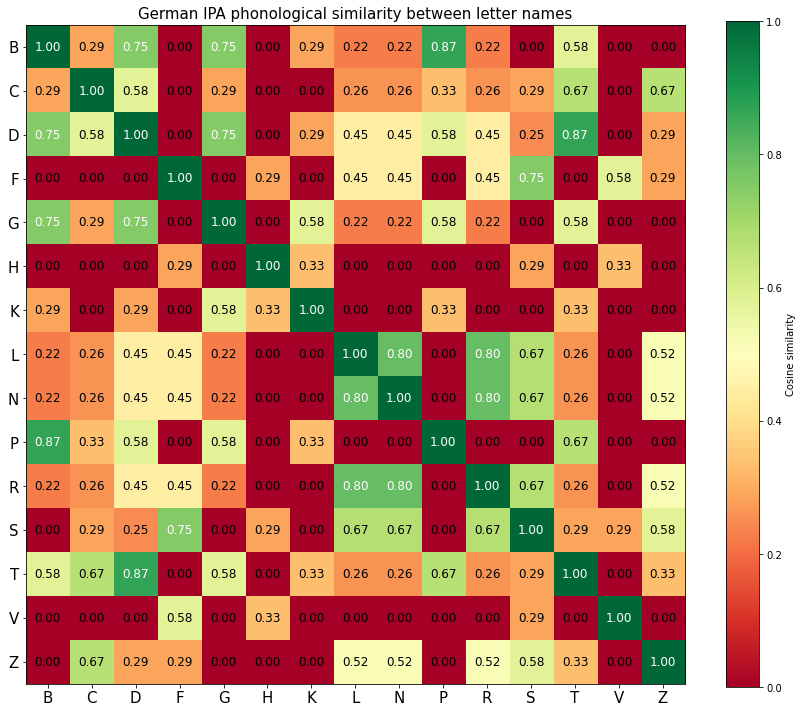

In [11]:
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(COS_SIM, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(15))
ax.set_yticks(range(15))
ax.set_xticklabels(LETTERS, fontsize=15)
ax.set_yticklabels(LETTERS, fontsize=15)
plt.colorbar(im, ax=ax, label='Cosine similarity')
ax.set_title('German IPA phonological similarity between letter names', fontsize=15)

for i in range(15):
    for j in range(15):
        ax.text(j, i, f'{COS_SIM[i,j]:.2f}',
                ha='center', va='center', fontsize=12,
                color='black' if COS_SIM[i,j] < 0.7 else 'white')

plt.tight_layout()
plt.savefig('phon_similarity_matrix.pdf', dpi=150)
plt.show()

## 9. Serial Position Analysis (IN trials, all set sizes)

```
RT ~ serial_pos_norm_c + C(size) + (1 | subject)
```

`serial_pos_norm_c` is grand-mean centred (within the IN subset).
`C(size)` controls for overall RT differences across memory loads (reference: set size 4).


In [12]:
# ── 9.1  Compute normalised serial position for IN trials ────────────────

def get_serial_pos(row, letter_sets):
    """0-based probe position in string for IN trials, NaN otherwise."""
    if row["trial_type"] != "IN":
        return float("nan")
    letters = letter_sets[row.name]
    try:
        return float(letters.index(row["probe"]))
    except ValueError:
        return float("nan")

df["serial_pos"]      = [get_serial_pos(r, allL) for _, r in df.iterrows()]
df["serial_pos_norm"] = df["serial_pos"] / (df["size"].astype(int) - 1)  # [0, 1]

In [13]:
# ── 9.2  LME: RT ~ serial_pos_norm_c + C(size) + (1|subject), IN trials ─

import statsmodels.formula.api as smf

df_in = df[df["trial_type"] == "IN"].dropna(subset=["serial_pos_norm", "rt"]).copy()
df_in["serial_pos_norm_c"] = df_in["serial_pos_norm"] - df_in["serial_pos_norm"].mean()

# Set size 4 as reference level
df_in["size"] = df_in["size"].cat.reorder_categories([4, 6, 8])

model_pos = smf.mixedlm(
    "rt ~ serial_pos_norm_c + C(size)",
    data=df_in,
    groups=df_in["subject"],
    re_formula="1"
)
res_pos = model_pos.fit(reml=False)
print(res_pos.summary())


           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  rt        
No. Observations:   1122     Method:              ML        
No. Groups:         11       Scale:               0.4864    
Min. group size:    62       Log-Likelihood:      -1203.7740
Max. group size:    149      Converged:           Yes       
Mean group size:    102.0                                   
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept          1.397    0.095 14.754 0.000  1.211  1.582
C(size)[T.6]       0.185    0.049  3.767 0.000  0.089  0.281
C(size)[T.8]       0.228    0.053  4.334 0.000  0.125  0.330
serial_pos_norm_c -0.007    0.058 -0.116 0.908 -0.121  0.107
Group Var          0.087    0.057                           



In [14]:
# ── Compute serial position for IN trials (for main model) ────────────────
# serial_pos and serial_pos_norm are already computed above (section 9.1).
# For the main model we need a predictor defined on ALL trials:
#   - IN trials: normalised position ∈ [0, 1]  (0 = first, 1 = last)
#   - OUT trials: 0  (zero-coded, so OUT trials contribute zero to the slope)
# Mean-centring is done over IN trials only, then OUT trials stay at −mean,
# which means the intercept reflects the grand mean RT at the mean serial
# position of IN trials. If you prefer centring over all trials (so OUT=0
# becomes part of the distribution), swap the mean accordingly.

df["serial_pos_norm_IN"] = df["serial_pos_norm"].fillna(0.0)

# Centre over IN trials only (so the slope is interpretable as the effect
# of serial position within the IN condition)
_in_mean = df.loc[df["trial_type"] == "IN", "serial_pos_norm_IN"].mean()
df["serial_pos_norm_IN_c"] = df["serial_pos_norm_IN"] - _in_mean
# OUT trials end up at 0 − _in_mean ≈ −0.5, which is fine:
# the C(trial_type) term absorbs the IN/OUT mean difference,
# and serial_pos_norm_IN_c captures within-IN serial-position variance.

formula = (
    'rt ~ predicted_c'
    ' + phon_sim_c'
    ' + probe_phon_sim_c'
    #' + letter_freq_session_c'
    #' + letter_freq_subj_c'
    #' + letter_freq_global_c'
    #' + letter_cum_session_c'
    #' + letter_cum_subj_c'
    ' + C(trial_type)'
    ' + C(size)'
    ' + C(probe)'
    #' + serial_pos_norm_IN_c'
)

model = smf.mixedlm(
    formula,
    df,
    groups=df['subject'],
    re_formula='1'   # random intercept per participant
)

res = model.fit(reml=False)
print(res.summary())

            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   rt        
No. Observations:   2585      Method:               ML        
No. Groups:         11        Scale:                0.5084    
Min. group size:    149       Log-Likelihood:       -2815.5323
Max. group size:    338       Converged:            Yes       
Mean group size:    235.0                                     
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            1.448    0.120 12.077 0.000  1.213  1.683
C(trial_type)[T.IN] -0.146    0.028 -5.145 0.000 -0.201 -0.090
C(size)[T.6]         0.218    0.033  6.543 0.000  0.153  0.283
C(size)[T.8]         0.341    0.035  9.612 0.000  0.272  0.411
C(probe)[T.B]        0.100    0.079  1.264 0.206 -0.055  0.255
C(probe)[T.C]        0.185    0.080  2.319 0.020  0.029  0.341
C(pro

In [15]:
import numpy as np

# ── 1. Z-score RT at subject × session level ─────────────────────────────
# Use subject-level if sessions are same-day / not meaningfully separated.
# Use subject × session if sessions span different days.

# Option A – subject level
df["rt_z"] = (
    df.groupby("subject")["rt"]
      .transform(lambda x: (x - x.mean()) / x.std(ddof=1))
)

# Option B – subject × session level (recommended if multi-day)
# df["rt_z"] = (
#     df.groupby(["subject", "session"])["rt"]
#       .transform(lambda x: (x - x.mean()) / x.std(ddof=1))
# )

# ── 2. Z-score continuous predictors (subject level) ─────────────────────
# Already centred — now also scale by within-subject SD so that
# a unit change = 1 SD, and coefficients are comparable across predictors.

def zscore_by_subject(col):
    return df.groupby("subject")[col].transform(
        lambda x: (x - x.mean()) / x.std(ddof=1)
    )

df["predicted_z"]   = zscore_by_subject("predicted_c")   # or raw 'predicted'
df["phon_sim_z"]    = zscore_by_subject("phon_sim_c")
df["probe_phon_sim_z"] = zscore_by_subject("probe_phon_sim_c")

# ── 3. Serial position: z-score the centred version by subject ────────────
df["serial_pos_norm_IN"] = df["serial_pos_norm"].fillna(0.0)
_in_mean = df.loc[df["trial_type"] == "IN", "serial_pos_norm_IN"].mean()
df["serial_pos_norm_IN_c"] = df["serial_pos_norm_IN"] - _in_mean

df["serial_pos_z"] = zscore_by_subject("serial_pos_norm_IN_c")
# Note: OUT trials (coded 0 before centering) will have a fixed negative
# z-score within each subject — that's fine, C(trial_type) absorbs the mean.

# ── 4. Model with z-scored variables ─────────────────────────────────────
formula = (
    'rt ~ predicted_z'
    ' + phon_sim_z'
    ' + probe_phon_sim_z'
    ' + C(trial_type)'
    ' + C(size)'
    ' + C(probe)'
    #' + serial_pos_z'
)

model = smf.mixedlm(
    formula,
    df,
    groups=df["subject"],
    re_formula="1"
)
res = model.fit(reml=False)
print(res.summary())

            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   rt        
No. Observations:   2585      Method:               ML        
No. Groups:         11        Scale:                0.5083    
Min. group size:    149       Log-Likelihood:       -2815.1964
Max. group size:    338       Converged:            Yes       
Mean group size:    235.0                                     
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept            1.448    0.119 12.170 0.000  1.215  1.681
C(trial_type)[T.IN] -0.146    0.028 -5.143 0.000 -0.201 -0.090
C(size)[T.6]         0.217    0.033  6.525 0.000  0.152  0.283
C(size)[T.8]         0.341    0.035  9.600 0.000  0.271  0.410
C(probe)[T.B]        0.100    0.079  1.261 0.207 -0.055  0.254
C(probe)[T.C]        0.185    0.080  2.323 0.020  0.029  0.341
C(pro

In [16]:
predictor_cols = ["predicted_z", "phon_sim_z", "probe_phon_sim_z", "serial_pos_z"]
corr_matrix = df[predictor_cols].corr()
print(corr_matrix.round(3))

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

predictor_cols = ["predicted_z", "phon_sim_z", "probe_phon_sim_z", "serial_pos_z"]
X = df[predictor_cols].dropna()

vif_df = pd.DataFrame({
    "predictor": predictor_cols,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif_df)

def within_sub_corr(df, col1, col2):
    return (
        df.groupby("subject")
          .apply(lambda g: g[[col1, col2]].corr().iloc[0, 1])
          .describe()  # mean, SD, min, max across subjects
    )

print(within_sub_corr(df, "predicted_z", "phon_sim_z"))
print(within_sub_corr(df, "predicted_z", "probe_phon_sim_z"))
print(within_sub_corr(df, "phon_sim_z", "probe_phon_sim_z"))

                  predicted_z  phon_sim_z  probe_phon_sim_z  serial_pos_z
predicted_z             1.000       0.022             0.018        -0.006
phon_sim_z              0.022       1.000             0.367         0.031
probe_phon_sim_z        0.018       0.367             1.000         0.020
serial_pos_z           -0.006       0.031             0.020         1.000
          predictor       VIF
0       predicted_z  1.000630
1        phon_sim_z  1.156592
2  probe_phon_sim_z  1.155752
3      serial_pos_z  1.001097
count    11.000000
mean      0.028349
std       0.084138
min      -0.081071
25%      -0.031652
50%       0.009019
75%       0.094762
max       0.175309
dtype: float64
count    11.000000
mean      0.020702
std       0.045742
min      -0.060559
25%      -0.003329
50%       0.020173
75%       0.049864
max       0.100955
dtype: float64
count    11.000000
mean      0.353692
std       0.118458
min       0.044026
25%       0.340776
50%       0.384278
75%       0.409601
max       0.4

In [21]:
import re
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests

# ── Extract fixed effects ─────────────────────────────────────────────────
fe_params = res.fe_params
fe_se     = res.bse_fe
conf_int  = res.conf_int().loc[fe_params.index]
fe_pvals  = res.pvalues.loc[fe_params.index]
z_values  = fe_params / fe_se

ci_strings = conf_int.apply(
    lambda r: f'[{r[0]:.3f}, {r[1]:.3f}]', axis=1
)

# ── FDR correction within probe and size families ─────────────────────────
probe_mask = fe_pvals.index.str.startswith('C(probe)')
size_mask  = fe_pvals.index.str.startswith('C(size)')

_, probe_fdr, _, _ = multipletests(fe_pvals[probe_mask], method='fdr_bh')
_, size_fdr,  _, _ = multipletests(fe_pvals[size_mask],  method='fdr_bh')

# Start with raw p-values, overwrite corrected families in place
pval_display = fe_pvals.copy()
pval_display[probe_mask] = probe_fdr
pval_display[size_mask]  = size_fdr

def fmt_p(p):
    return f'{p:.2e}'

# ── Build results table ───────────────────────────────────────────────────
results_table = pd.DataFrame({
    'Coefficient': fe_params.round(3),
    'CI':          ci_strings,
    'z-value':     z_values.round(3),
    'p-value':     pval_display.apply(fmt_p),
}, index=fe_params.index)

# ── Rename terms to human-readable labels ─────────────────────────────────
RENAME = {
    'Intercept':        'Intercept',
    'predicted_z':      'Decoding accuracy',
    'phon_sim_z':       'Phonological similarity (string)',
    'probe_phon_sim_z': 'Phonological similarity (probe–string)',
    'serial_pos_z':     'Serial position (IN trials)',
}

def clean_term(term):
    if term in RENAME:
        return RENAME[term]
    m = re.match(r'C\((?P<var>[^)]+)\)\[T\.(?P<lvl>.+)\]$', term)
    if m:
        var, lvl = m.group('var'), m.group('lvl')
        ref = df[var].cat.categories[0]
        return f'{lvl} vs. {ref}'
    return term

results_table.index = [clean_term(t) for t in results_table.index]

# ── Reorder: key predictors first, covariates after ───────────────────────
PRIORITY = [
    'Intercept',
    'Decoding accuracy',
    'Phonological similarity (string)',
    'Phonological similarity (probe–string)',
    'Serial position (IN trials)',
]
idx_order     = PRIORITY + [x for x in results_table.index if x not in PRIORITY]
results_table = results_table.reindex(
    [x for x in idx_order if x in results_table.index]
)

# ── Export ────────────────────────────────────────────────────────────────
results_table.to_excel('Mixed-effect_RT.xlsx')
results_table

,Coefficient,CI,z-value,p-value
Intercept,1.448,"[1.215, 1.681]",12.170,4.48e-34
Decoding accuracy,-0.034,"[-0.062, -0.006]",-2.397,1.65e-02
Phonological similarity (string),-0.044,"[-0.074, -0.013]",-2.806,5.01e-03
Phonological similarity (probe–string),0.075,"[0.034, 0.115]",3.629,2.85e-04
IN vs. OUT,-0.146,"[-0.201, -0.090]",-5.143,2.70e-07
6 vs. 4,0.217,"[0.152, 0.283]",6.525,6.78e-11
8 vs. 4,0.341,"[0.271, 0.410]",9.600,1.61e-21
B vs. G,0.100,"[-0.055, 0.254]",1.261,4.84e-01
C vs. G,0.185,"[0.029, 0.341]",2.323,2.07e-01
D vs. G,0.046,"[-0.110, 0.202]",0.576,7.84e-01


In [20]:
# ── Save dataframe for R analysis ────────────────────────────────────────
# Saves the columns needed by glm.R:
#   - rt, subject, trial_type, size, probe        (outcome + factors)
#   - predicted, phon_sim, probe_phon_sim          (raw continuous predictors;
#                                                   R re-does the centring + z-scoring)

cols_to_save = [
    'rt',
    'subject',
    'trial_type',
    'size',
    'probe',
    'predicted',
    'phon_sim',
    'probe_phon_sim',
]

df[cols_to_save].to_csv('table_df.csv', index=False)
print(f'Saved {len(df)} rows × {len(cols_to_save)} cols to table_df.csv')

Saved 2585 rows × 8 cols to table_df.csv


In [18]:
# ── 11. Serial Position as Sole Predictor — IN Trials Only ───────────────────
# Model: RT ~ serial_pos_z + C(size) + (1 | subject)
# No phonological or decoding predictors — isolates pure positional effect.

df_pos = df[df['trial_type'] == 'IN'].copy()

# Compute normalised serial position [0, 1]
df_pos['serial_pos_norm'] = df_pos.apply(
    lambda row: float(allL[row.name].index(row['probe'])) / (int(str(row['size'])) - 1)
    if row['probe'] in allL[row.name] else float('nan'),
    axis=1
)
df_pos = df_pos.dropna(subset=['serial_pos_norm', 'rt'])

# Centre and z-score within subject
df_pos['serial_pos_norm_c'] = (
    df_pos['serial_pos_norm'] - df_pos['serial_pos_norm'].mean()
)
df_pos['serial_pos_z'] = df_pos.groupby('subject')['serial_pos_norm_c'].transform(
    lambda x: (x - x.mean()) / x.std(ddof=1)
)

# Set size reference = 4
df_pos['size'] = df_pos['size'].cat.reorder_categories([4, 6, 8])

# Fit model
model_pos_only = smf.mixedlm(
    'rt ~ serial_pos_z + C(size)',
    df_pos,
    groups=df_pos['subject'],
    re_formula='1'
)
res_pos_only = model_pos_only.fit(reml=False)
print(res_pos_only.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: rt        
No. Observations: 1122    Method:             ML        
No. Groups:       11      Scale:              0.4864    
Min. group size:  62      Log-Likelihood:     -1203.7799
Max. group size:  149     Converged:          Yes       
Mean group size:  102.0                                 
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      1.397    0.095 14.754 0.000  1.211  1.582
C(size)[T.6]   0.184    0.049  3.764 0.000  0.088  0.280
C(size)[T.8]   0.228    0.053  4.336 0.000  0.125  0.331
serial_pos_z  -0.001    0.021 -0.039 0.969 -0.042  0.040
Group Var      0.087    0.057                           



In [19]:
perc4 = np.mean(df['size']==4)
perc6 = np.mean(df['size']==6)
perc8 = np.mean(df['size']==8)

print(perc4, perc6, perc8)

0.46073500967117986 0.2967117988394584 0.2425531914893617
